In [1]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import albumentations as A

from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
TRAIN_PATH = "../../dataset/noise_removed/train"
TEST_PATH = "../../dataset/noise_removed/test"

SUBMISSION_PATH = "../../samplesubmission.csv"

In [4]:
classes = [
    "fake_mannequin",
    "fake_mask",
    "fake_printed",
    "fake_screen",
    "fake_unknown",
    "realperson"
]

label2id = {c:i for i,c in enumerate(classes)}
id2label = {i:c for c,i in label2id.items()}

label2id

{'fake_mannequin': 0,
 'fake_mask': 1,
 'fake_printed': 2,
 'fake_screen': 3,
 'fake_unknown': 4,
 'realperson': 5}

In [5]:
data = []

for label in classes:

    folder = os.path.join(TRAIN_PATH, label)

    for img in os.listdir(folder):

        data.append({
            "path": os.path.join(folder, img),
            "label": label2id[label]
        })

train_df = pd.DataFrame(data)

print("Total training images:", len(train_df))
train_df.head()

Total training images: 1454


,path,label
0,../../dataset/noise_removed/train\fake_mannequ...,0
1,../../dataset/noise_removed/train\fake_mannequ...,0
2,../../dataset/noise_removed/train\fake_mannequ...,0
3,../../dataset/noise_removed/train\fake_mannequ...,0
4,../../dataset/noise_removed/train\fake_mannequ...,0


In [6]:
model_name = 'resnet50' 

model = timm.create_model(
    model_name, 
    pretrained=True, 
    num_classes=6
)

model = model.to(device)
print(f"Model {model_name} berhasil dimuat.")

Model resnet50 berhasil dimuat.


In [7]:
train_tfms = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussianBlur(p=0.2),
    A.ColorJitter(p=0.3),
    #Normalize ImageNet nya
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

test_tfms = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

In [8]:
class FaceDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row.path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(image=img)["image"]

        #  (H, W, C) jadi (C, H, W)
        img = np.transpose(img, (2, 0, 1))
        label = row.label

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [9]:
train_dataset = FaceDataset(train_df, train_tfms)
train_loader = DataLoader(
    train_dataset,
    batch_size=32, 
    shuffle=True,
    num_workers=0
)

In [10]:
model_name = "resnet50" 
model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=6
)

In [11]:
model = model.to(device)
print(f"Model {model_name} loaded")

Model resnet50 loaded


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

In [13]:
def train_one_epoch(loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

In [14]:
EPOCHS = 15
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")

100%|██████████| 46/46 [00:31<00:00,  1.48it/s]


Epoch 1/15 | Loss: 1.5111 | Acc: 0.4182


100%|██████████| 46/46 [00:30<00:00,  1.49it/s]


Epoch 2/15 | Loss: 0.7742 | Acc: 0.7469


100%|██████████| 46/46 [00:30<00:00,  1.49it/s]


...

Epoch 13/15 | Loss: 0.0557 | Acc: 0.9828


100%|██████████| 46/46 [00:30<00:00,  1.50it/s]


Epoch 14/15 | Loss: 0.0528 | Acc: 0.9862


100%|██████████| 46/46 [00:30<00:00,  1.49it/s]

Epoch 15/15 | Loss: 0.0457 | Acc: 0.9862


In [15]:
submission_df = pd.read_csv(SUBMISSION_PATH)
test_paths = []
for img_id in submission_df["id"]:
    found = False
    for ext in [".jpg", ".jpeg", ".png"]:
        path = os.path.join(TEST_PATH, str(img_id) + ext)
        if os.path.exists(path):
            test_paths.append(path)
            found = True
            break
    if not found: test_paths.append(None)

test_df = pd.DataFrame({"path": test_paths})

In [16]:
torch.save(model.state_dict(), "resnet50_model.pth")
print("ResNet-50 Model saved.")

ResNet-50 Model saved.


In [17]:
class TestDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df
        self.transforms = transforms
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        path = self.df.iloc[idx].path
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transforms:
            img = self.transforms(image=img)["image"]
        img = np.transpose(img, (2, 0, 1))
        return torch.tensor(img, dtype=torch.float32)


test_dataset = TestDataset(test_df, test_tfms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [18]:
model.eval()
predictions = []
with torch.no_grad():
    for imgs in tqdm(test_loader, desc="Inference"):
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        predictions.extend(preds)

submission_df["label"] = [id2label[p] for p in predictions]
submission_df.to_csv("submission_resnet50.csv", index=False)
print("Submission file saved!")

Inference: 100%|██████████| 13/13 [00:08<00:00,  1.59it/s]

Submission file saved!


In [19]:
submission_df["label"] = [id2label[p] for p in predictions]

submission_df.head()

,id,label
0,test_001,fake_screen
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed


In [20]:
submission_df.to_csv("submission.csv", index=False)

print("Submission saved.")

Submission saved.


In [21]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [22]:
pred_df = pd.read_csv("submission.csv")
anot_df = pd.read_csv("../../samplesubmission_anotated_final.csv", sep=";")

print("Prediction shape:", pred_df.shape)
print("Anotated:", anot_df.shape)

pred_df.head()

Prediction shape: (404, 2)
Anotated: (404, 2)


,id,label
0,test_001,fake_screen
1,test_002,fake_mannequin
2,test_003,realperson
3,test_004,realperson
4,test_005,fake_printed


In [23]:
df = anot_df.merge(pred_df, on="id", suffixes=("_anot", "_pred"))

df.head()

,id,label_anot,label_pred
0,test_001,fake_screen,fake_screen
1,test_002,fake_mannequin,fake_mannequin
2,test_003,realperson,realperson
3,test_004,realperson,realperson
4,test_005,fake_screen,fake_printed


In [24]:
df["y_true"] = df["label_anot"].map(label2id)
df["y_pred"] = df["label_pred"].map(label2id)

In [25]:
macro_f1 = f1_score(df["y_true"], df["y_pred"], average="macro")

print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.9007177726692622


In [26]:
print(classification_report(
    df["y_true"],
    df["y_pred"],
    target_names=classes
))

                precision    recall  f1-score   support

fake_mannequin       0.87      1.00      0.93        47
     fake_mask       0.83      0.94      0.88        66
  fake_printed       0.88      0.82      0.84        60
   fake_screen       0.95      0.85      0.90        74
  fake_unknown       0.92      0.94      0.93        50
    realperson       0.94      0.90      0.92       107

      accuracy                           0.90       404
     macro avg       0.90      0.91      0.90       404
  weighted avg       0.90      0.90      0.90       404



In [27]:
cm = confusion_matrix(df["y_true"], df["y_pred"])

cm

array([[47,  0,  0,  0,  0,  0],
       [ 1, 62,  1,  0,  1,  1],
       [ 1,  4, 49,  2,  0,  4],
       [ 2,  0,  5, 63,  3,  1],
       [ 2,  0,  0,  1, 47,  0],
       [ 1,  9,  1,  0,  0, 96]])

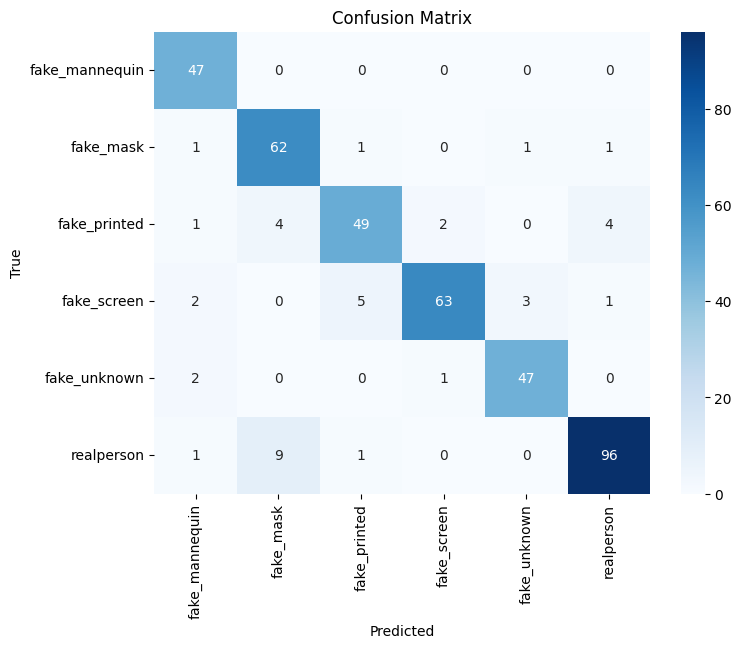

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

Total mistakes: 40


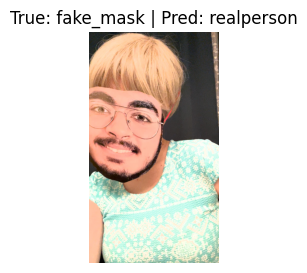

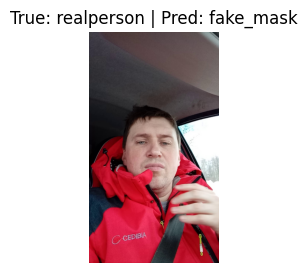

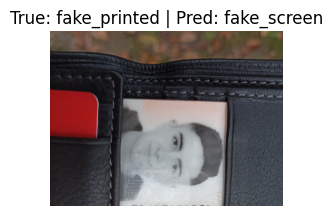

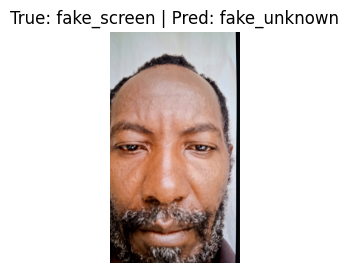

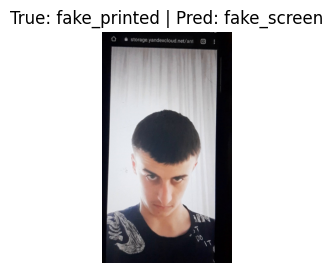

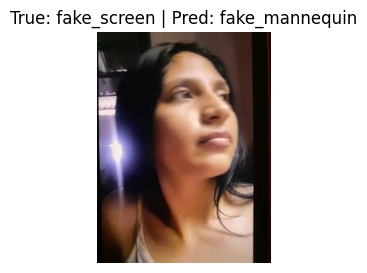

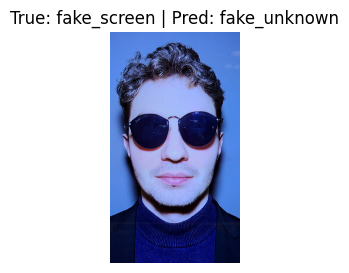

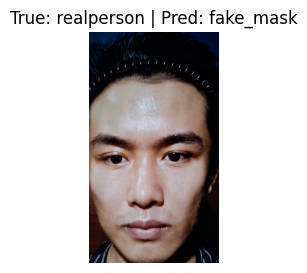

In [29]:
import random
import matplotlib.pyplot as plt

mistakes = df[df["label_anot"] != df["label_pred"]]

print("Total mistakes:", len(mistakes))

sample = mistakes.sample(8)

for i,row in sample.iterrows():

    img_id = row["id"]
    path = os.path.join(TEST_PATH, img_id + ".jpg")

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"True: {row['label_anot']} | Pred: {row['label_pred']}")
    plt.axis("off")